# Task 2 — Clustering of CRISPR perturbations

Which perturbations produce similar transcriptional effects, and which clustering method
recovers the structure best?


1. **Conditions are represented explicitly.** Section 1 uses a condition map so
   variable names cannot silently determine labels.
2. **The main analysis clusters perturbation effects, not cells or absolute expression.**
   `obs['perturbation']` names a single
   target per cell, but 26–38 % of cells carry two or more guides (`obs['MOI']`), so the
   cell-level label is only an arbitrary member of that cell's target set. The exploratory
   notebook already averaged expression by perturbation; here the 248 × 23,712 matrix uses
   single-target cells and same-condition clean-control log2FC instead.
3. **The exploratory diagnostics are retained and extended.** k-means elbow/silhouette sweeps
   and perturbation-level Leiden resolution sweeps are evaluated on the same filtered
   signature matrix used by every other method.
4. **Methods are scored against reference pathway labels** (Sections 3–4) and against a
   bootstrap resampling of cells within perturbations, rather than compared by eye.
5. **Effects are interpreted after clustering.** Ranked perturbation effects and cluster
   centroid/contrast genes are derived from the same cached clean-control log2FC and SE
   matrices.

All inputs are the Phase-0 caches; see `data/CACHE_PROVENANCE.json`.

log2FC convention throughout: `(mean log1p CP10K[perturbed] − mean log1p CP10K[control]) / ln 2`,
i.e. a **difference of log-scale means**, not the log of a ratio of means. Controls are
guide-derived clean controls (cells with zero targeting guides), not the `perturbation == 'control'`
label — 18,258 cells carrying that label do have targeting guides.

In [1]:
import os
os.environ.setdefault('NUMBA_CACHE_DIR', '/tmp/numba_cache')
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '8')
os.makedirs(os.environ['NUMBA_CACHE_DIR'], exist_ok=True)

import gc, json, pickle, time
from importlib.metadata import version
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
import scanpy as sc

from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans, DBSCAN, HDBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.metrics import (adjusted_rand_score as ARI,
                             adjusted_mutual_info_score as AMI,
                             silhouette_score)
import igraph as ig
import leidenalg

CONDS    = ['Co_culture', 'Control', 'IFNg']
COND_MAP = {'Co_culture': 'Co-culture', 'Control': 'Control', 'IFNg': 'IFN\u03b3'}
CONDLAB  = {'Co_culture': 'Co-culture (TILs)', 'Control': 'Control', 'IFNg': 'IFN-\u03b3'}
CCOL     = {'Co_culture': '#2166ac', 'IFNg': '#b2182b', 'Control': '#888888'}
JS       = ['IFNGR1', 'IFNGR2', 'JAK1', 'JAK2', 'STAT1']

os.makedirs('figures', exist_ok=True)
print(version('scanpy'))

1.12.1


## 1 Cell-level diagnostic, per condition

### 1.1 Condition-label provenance

this notebook avoids condition-named AnnData variables altogether by indexing
a single explicit `COND_MAP`. The cell-level analysis below is retained only as a diagnostic:
the inferential clustering starts from single-target pseudo-bulk effects in Section 2.

In [2]:
adata = sc.read_h5ad('data/dataset_hv.h5ad')     # 216,431 x 1,011, CP10K + log1p, PCA/neighbours/UMAP present
adata

AnnData object with n_obs × n_vars = 216431 × 1011
    obs: 'cell_name', 'condition', 'perturbation', 'pert_label', 'guide_id', 'MOI', 'n_targeting_guides', 'n_guide_tokens', 'ncounts', 'ngenes', 'percent_mito', 'nperts', 'qc_pass', 'is_single_pert', 'is_clean_control'
    var: 'highly_variable', 'paper_marker', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'neighbors', 'pca', 'pseudobulk_provenance', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: 'counts', None (.X)

In [3]:
# Explicit mapping: displayed condition labels are resolved once, not encoded in variable names.
COND_MASK = {c: (adata.obs.condition == COND_MAP[c]).values for c in CONDS}

pd.DataFrame({'n_cells':     {c: int(m.sum()) for c, m in COND_MASK.items()},
              'frac_MOI>=2': {c: round(float((adata.obs.MOI.values[m] >= 2).mean()), 3)
                              for c, m in COND_MASK.items()},
              'max_MOI':     {c: int(adata.obs.MOI.values[m].max()) for c, m in COND_MASK.items()}})

,n_cells,frac_MOI>=2,max_MOI
Co_culture,72398,0.261,12
Control,57039,0.384,19
IFNg,86994,0.310,14


26–38 % of cells in each condition carry two or more guides, with up to 19 in one cell. For
those cells `obs['perturbation']` names one arbitrary member of the target set, so any
cell-level analysis keyed on that column mixes effects.

In [4]:
# Each condition is embedded and clustered on its own cells, then reduced to a small
# per-cell table. The AnnData subset is released before the next condition so that peak
# memory stays at one condition rather than three.
def cluster_one_condition(a):
    sc.pp.pca(a, n_comps=50)
    sc.pp.neighbors(a)
    sc.tl.umap(a)
    sc.tl.leiden(a, resolution=0.7, flavor='igraph', n_iterations=2, directed=False,
                 random_state=123, key_added='leiden')
    sc.tl.louvain(a, resolution=1.0, random_state=123, key_added='louvain')
    a.obs['kmeans'] = KMeans(n_clusters=15, random_state=123, n_init=10
                             ).fit_predict(a.obsm['X_pca']).astype(str)
    return pd.DataFrame({'perturbation': a.obs.perturbation.values,
                         'MOI': a.obs.MOI.values,
                         'is_single_pert': a.obs.is_single_pert.values,
                         'leiden': a.obs.leiden.astype(str).values,
                         'louvain': a.obs.louvain.astype(str).values,
                         'kmeans': a.obs.kmeans.values,
                         'umap1': a.obsm['X_umap'][:, 0],
                         'umap2': a.obsm['X_umap'][:, 1]})

CELLDF = {}
for c in CONDS:
    sub_a = adata[COND_MASK[c]].copy()
    CELLDF[c] = cluster_one_condition(sub_a)
    del sub_a; gc.collect()
    print(c, CELLDF[c].shape, 'leiden', CELLDF[c].leiden.nunique(),
          'louvain', CELLDF[c].louvain.nunique())

del adata; gc.collect()

Co_culture (72398, 8) leiden 8 louvain 11
Control (57039, 8) leiden 7 louvain 12
IFNg (86994, 8) leiden 7 louvain 9


760

In [5]:
def dominant_cluster(df, key):
    rows = []
    for p, g in df.groupby('perturbation', observed=True)[key]:
        vc = g.value_counts()
        if vc.sum() == 0:
            continue
        rows.append(dict(perturbation=p, cluster=str(vc.idxmax()),
                         cluster_score=round(vc.max() / vc.sum() * 100, 2), n_cells=int(vc.sum())))
    return pd.DataFrame(rows)

CELLTAB = {c: {k: dominant_cluster(CELLDF[c], k) for k in ['leiden', 'louvain', 'kmeans']}
           for c in CONDS}

CELL_SUMMARY = pd.DataFrame([
    dict(condition=c, method=k,
         n_clusters=CELLTAB[c][k].cluster.nunique(),
         median_cluster_score=round(CELLTAB[c][k].cluster_score.median(), 2),
         max_cluster_score=round(CELLTAB[c][k].cluster_score.max(), 2),
         frac_below_40pct=round((CELLTAB[c][k].cluster_score < 40).mean(), 3))
    for c in CONDS for k in ['leiden', 'louvain', 'kmeans']])
CELL_SUMMARY

,condition,method,n_clusters,median_cluster_score,max_cluster_score,frac_below_40pct
0,Co_culture,leiden,8,23.08,62.11,0.968
1,Co_culture,louvain,9,17.05,42.86,0.988
2,Co_culture,kmeans,15,12.55,49.74,0.980
3,Control,leiden,6,24.16,66.67,0.980
4,Control,louvain,9,16.84,75.00,0.980
5,Control,kmeans,12,13.21,50.00,0.984
6,IFNg,leiden,6,26.15,73.08,0.960
7,IFNg,louvain,7,20.27,75.00,0.972
8,IFNg,kmeans,14,11.82,49.04,0.992


`cluster_score` is the percentage of a target's cells falling in that target's single most
common cluster. Median across targets is 12–24 %
and 96–99 % of targets sit below 40 %, i.e. for almost every target the cells are spread
across clusters rather than concentrated in one.

In [6]:
# The corrected per-condition dominant Leiden cluster for the IFN-\u03b3/JAK-STAT core
pd.DataFrame({c: {g: '%s (%.1f%%)' % (t.loc[g, 'cluster'], t.loc[g, 'cluster_score'])
                  for g in JS if g in t.index}
              for c, t in ((c, CELLTAB[c]['leiden'].set_index('perturbation')) for c in CONDS)})

,Co_culture,Control,IFNg
IFNGR1,1 (58.1%),5 (25.8%),4 (60.2%)
IFNGR2,1 (49.6%),0 (24.4%),4 (57.8%)
JAK1,1 (57.5%),1 (23.0%),4 (55.5%)
JAK2,1 (57.1%),1 (23.9%),4 (57.3%)
STAT1,1 (62.1%),0 (21.0%),4 (73.1%)


In [7]:
# How much perturbation identity do the cell clusters carry?
# Restricted to single-guide cells, where obs['perturbation'] is unambiguous.
CELLARI = []
for c in CONDS:
    d = CELLDF[c]
    m = d.is_single_pert.values & (d.perturbation != 'control').values
    for k in ['leiden', 'louvain', 'kmeans']:
        CELLARI.append(dict(condition=c, method=k, n_cells_single=int(m.sum()),
                            ari_vs_perturbation=round(ARI(d.perturbation.values[m], d[k].values[m]), 4),
                            ami_vs_perturbation=round(AMI(d.perturbation.values[m], d[k].values[m]), 4)))
CELLARI = pd.DataFrame(CELLARI)
CELLARI

,condition,method,n_cells_single,ari_vs_perturbation,ami_vs_perturbation
0,Co_culture,leiden,40352,0.0020,0.0205
1,Co_culture,louvain,40352,0.0013,0.0165
2,Co_culture,kmeans,40352,0.0033,0.0206
3,Control,leiden,26463,0.0000,0.0012
4,Control,louvain,26463,0.0001,0.0019
5,Control,kmeans,26463,0.0001,0.0019
6,IFNg,leiden,43665,0.0007,0.0114
7,IFNg,louvain,43665,0.0009,0.0114
8,IFNg,kmeans,43665,0.0007,0.0076


ARI between cell clusters and perturbation identity is 0.0001–0.0033. The cell-level clusters
partition the cells on something other than which gene was knocked out. Section 2 therefore
moves to the perturbation level.

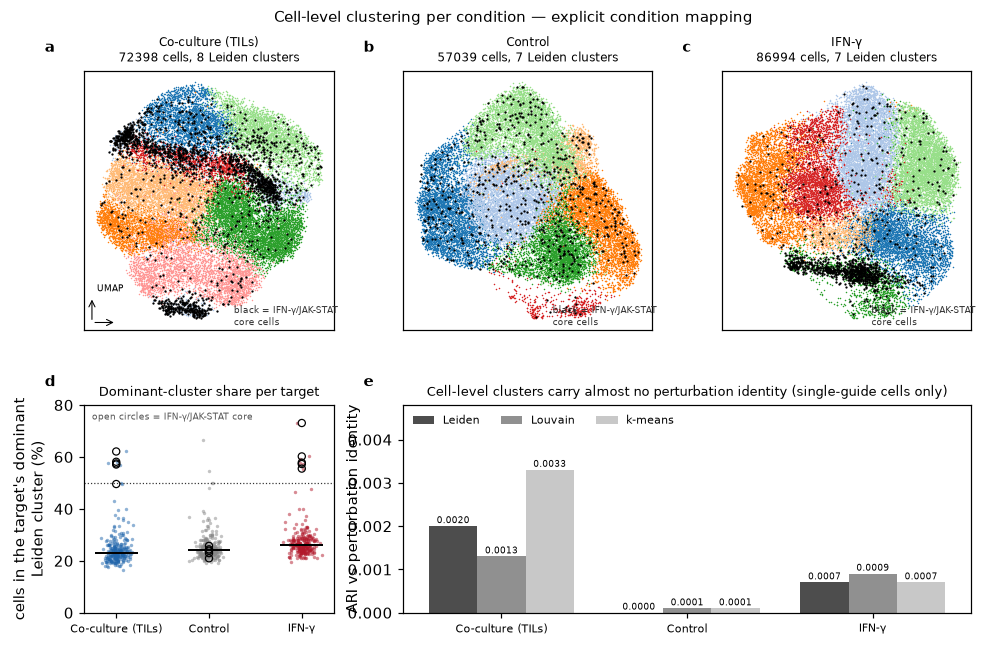

In [8]:
rng = np.random.default_rng(3)
fig = plt.figure(figsize=(10.4, 6.4))
gs  = fig.add_gridspec(2, 3, height_ratios=[1.25, 1.0], hspace=0.32, wspace=0.28)

for j, c in enumerate(CONDS):
    ax = fig.add_subplot(gs[0, j])
    d  = CELLDF[c]
    dd = d.iloc[rng.choice(len(d), size=min(25000, len(d)), replace=False)]
    cmap = plt.get_cmap('tab20')
    for k, cl in enumerate(sorted(dd.leiden.unique(), key=int)):
        m = (dd.leiden == cl).values
        ax.scatter(dd.umap1.values[m], dd.umap2.values[m], s=1.0, color=cmap(k % 20),
                   lw=0, rasterized=True)
    jm = (d.perturbation.isin(JS) & d.is_single_pert).values
    ax.scatter(d.umap1.values[jm], d.umap2.values[jm], s=2.2, color='black', lw=0, rasterized=True)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title('%s\n%d cells, %d Leiden clusters' % (CONDLAB[c], len(d), d.leiden.nunique()),
                 fontsize=8)
    if j == 0:
        ax.annotate('', xy=(0.13, 0.03), xytext=(0.03, 0.03), xycoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', lw=0.7))
        ax.annotate('', xy=(0.03, 0.13), xytext=(0.03, 0.03), xycoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', lw=0.7))
        ax.annotate('UMAP', xy=(0.05, 0.15), xycoords='axes fraction', fontsize=6)
    ax.annotate('black = IFN-\u03b3/JAK-STAT\ncore cells', xy=(0.60, 0.02),
                xycoords='axes fraction', fontsize=6, color='#333333')

ax = fig.add_subplot(gs[1, 0])
for k, c in enumerate(CONDS):
    s = CELLTAB[c]['leiden'].cluster_score.values
    ax.scatter(np.full(len(s), k) + rng.normal(0, 0.07, len(s)), s, s=5, color=CCOL[c],
               alpha=0.5, lw=0)
    ax.plot([k - 0.22, k + 0.22], [np.median(s)] * 2, color='black', lw=1.3, zorder=5)
    t = CELLTAB[c]['leiden'].set_index('perturbation')
    for g in JS:
        if g in t.index:
            ax.scatter([k], [t.loc[g, 'cluster_score']], s=22, facecolors='none',
                       edgecolors='black', lw=0.8, zorder=6)
ax.axhline(50, color='#333333', ls=':', lw=0.8)
ax.annotate('50 % (majority)', xy=(2.42, 51), fontsize=6, color='#555555', ha='right')
ax.set_xticks(range(3)); ax.set_xticklabels([CONDLAB[c] for c in CONDS], fontsize=7)
ax.set_ylabel("cells in the target's dominant\nLeiden cluster (%)"); ax.set_ylim(0, 80)
ax.set_title('Dominant-cluster share per target', fontsize=8.5)
ax.annotate('open circles = IFN-\u03b3/JAK-STAT core', xy=(0.03, 0.93), xycoords='axes fraction',
            fontsize=6, color='#555555')

ax = fig.add_subplot(gs[1, 1:])
xa, wa = np.arange(3), 0.26
for k, m in enumerate(['leiden', 'louvain', 'kmeans']):
    v = [float(CELLARI[(CELLARI.condition == c) & (CELLARI.method == m)].ari_vs_perturbation.iloc[0])
         for c in CONDS]
    ax.bar(xa + (k - 1) * wa, v, wa, color=['#4d4d4d', '#909090', '#c8c8c8'][k],
           label={'leiden': 'Leiden', 'louvain': 'Louvain', 'kmeans': 'k-means'}[m])
    for xi, vv in zip(xa + (k - 1) * wa, v):
        ax.annotate('%.4f' % vv, xy=(xi, vv), xytext=(0, 2), textcoords='offset points',
                    ha='center', fontsize=6)
ax.set_xticks(xa); ax.set_xticklabels([CONDLAB[c] for c in CONDS], fontsize=7)
ax.set_ylabel('ARI vs perturbation identity'); ax.set_ylim(0, 0.0048)
ax.yaxis.set_label_coords(-0.075, 0.5)
ax.legend(frameon=False, fontsize=7, ncol=3, loc='upper left')
ax.set_title('Cell-level clusters carry almost no perturbation identity (single-guide cells only)',
             fontsize=8.5)

for a_, l in zip(fig.axes, 'abcde'):
    a_.annotate(l, xy=(0, 1), xycoords='axes fraction', xytext=(-26, 10),
                textcoords='offset points', fontweight='bold', fontsize=10, va='bottom')
fig.suptitle('Cell-level clustering per condition \u2014 explicit condition mapping',
             fontsize=9.5, y=0.965)
fig.savefig('figures/task2_cell_level_clustering.png', dpi=200, bbox_inches='tight')

**Figure 1.** Cell-level clustering with explicit condition mapping.
(a–c) UMAP per condition coloured by Leiden cluster (25,000 cells subsampled for rendering;
clustering used all cells). Black points are all single-guide cells targeting the
IFN-γ/JAK-STAT core. (d) Fraction of each target's cells in that target's most common Leiden
cluster; black tick = median across targets. (e) Adjusted Rand index between cell clusters and
perturbation identity, single-guide cells only (n = 40,352 / 26,463 / 43,665). Higher = better.

In [9]:
gc.collect()
print('cell-level tables retained: %s' % {c: CELLDF[c].shape for c in CONDS})

cell-level tables retained: {'Co_culture': (72398, 8), 'Control': (57039, 8), 'IFNg': (86994, 8)}


## 2 Clustering the perturbation signature matrix

Each row of `data/rna_log2fc_<cond>.parquet` is one perturbation's mean log2FC across 23,712
genes relative to the clean controls of the same condition; `_se_` holds the matching standard
errors and `rna_ncells_` the number of cells contributing.

In [10]:
lf     = {c: pd.read_parquet(f'data/rna_log2fc_{c}.parquet')   for c in CONDS}
se     = {c: pd.read_parquet(f'data/rna_log2fc_se_{c}.parquet')       for c in CONDS}
ncells = {c: pd.read_parquet(f'data/rna_ncells_{c}.parquet')['n_cells'] for c in CONDS}
ctlmean= {c: pd.read_parquet(f'data/rna_control_mean_{c}.parquet') for c in CONDS}
{c: lf[c].shape for c in CONDS}

{'Co_culture': (248, 23712), 'Control': (248, 23712), 'IFNg': (248, 23712)}

### 2.1 Filtering and gene selection

Two filters, both needed because the cached matrices deliberately include every perturbation
with no minimum:

* **Perturbations**: ≥ 50 cells in that condition. Below that the row is dominated by sampling
  noise.
* **Genes**: rank by *excess variance* — the variance of log2FC across perturbations minus the
  mean squared standard error, which is the variance a purely-noise gene would show. Genes not
  detectably expressed in the controls (mean log1p ≤ 0.05) and the `MT-` family are excluded;
  without the mitochondrial exclusion the Control condition's top genes are all `MT-`, i.e.
  per-cell mitochondrial content rather than perturbation response.

In [11]:
MIN_CELLS, N_GENES = 50, 1500

keep = {c: ncells[c].index[ncells[c] >= MIN_CELLS].tolist() for c in CONDS}

def select_genes(c, n_genes=N_GENES, min_expr=0.05):
    L, S = lf[c].loc[keep[c]], se[c].loc[keep[c]]
    expressed = (ctlmean[c]['control_mean_log1p'] > min_expr).reindex(L.columns).fillna(False).values
    is_mito   = np.array([g.startswith('MT-') for g in L.columns])
    excess    = L.var(axis=0).values - (S.values ** 2).mean(axis=0)
    excess    = np.where(expressed & ~is_mito, excess, -np.inf)
    return list(L.columns[np.argsort(excess)[::-1][:n_genes]])

gsel = {c: select_genes(c) for c in CONDS}
pd.DataFrame({'n_perturbations': {c: len(keep[c]) for c in CONDS},
              'n_perts_dropped': {c: 248 - len(keep[c]) for c in CONDS},
              'top_5_genes':     {c: ', '.join(gsel[c][:5]) for c in CONDS}})

,n_perturbations,n_perts_dropped,top_5_genes
Co_culture,217,31,"CD74, HLA-B, B2M, HLA-DRA, HLA-DRB1"
Control,211,37,"TIMP1, CD63, MT2A, B2M, MSMP"
IFNg,220,28,"GBP1, STAT1, WARS, IRF1, IDO1"


In [12]:
def signature(c, L=None):
    L = (lf[c] if L is None else L).loc[keep[c], gsel[c]].astype(np.float64)
    Z = (L - L.mean(axis=0)) / L.std(axis=0).replace(0, np.nan)
    return Z.dropna(axis=1)

sig = {c: signature(c) for c in CONDS}
R   = {c: pd.DataFrame(np.corrcoef(sig[c].values), index=sig[c].index, columns=sig[c].index) for c in CONDS}
D   = {c: 1.0 - R[c] for c in CONDS}

# strongest correlated pairs per condition (sanity check on the distance structure)
for c in CONDS:
    r = R[c].where(np.triu(np.ones(R[c].shape, bool), 1)).stack().sort_values(ascending=False)
    print(c, ' | '.join('%s-%s %.2f' % (a, b, v) for (a, b), v in r.head(5).items()))

Co_culture IFNGR2-JAK2 0.92 | IFNGR1-IFNGR2 0.92 | JAK2-STAT1 0.92 | IFNGR2-STAT1 0.92 | IFNGR1-JAK2 0.92
Control CCND1-CDK6 0.53 | ACSL3-CCND1 0.36 | CTPS1-UQCRFS1 0.36 | ACSL3-CDK6 0.33 | CCND1-CKS1B 0.31
IFNg IFNGR2-STAT1 0.88 | IFNGR2-JAK2 0.87 | IFNGR1-IFNGR2 0.87 | JAK2-STAT1 0.87 | IFNGR1-JAK2 0.86


### 2.2 Choosing ε for DBSCAN from the k-distance curve

The sorted distance to each perturbation's 4th nearest neighbour. ε is placed at the largest
gap in the lower half of the curve — the point where the density of the tight core drops to
the density of the bulk.

In [13]:
def kdist(Dm, k=4):
    return np.sort(np.sort(Dm, axis=1)[:, k])

def eps_from_largest_gap(Dm, k=4, frac=0.5):
    kd = kdist(Dm, k)
    hi = int(len(kd) * frac)
    j  = int(np.argmax(np.diff(kd[:hi])))
    return float((kd[j] + kd[j + 1]) / 2)

Dmat = {}
EPS  = {}
for c in CONDS:
    Dm = D[c].values.copy(); np.fill_diagonal(Dm, 0.0)
    Dmat[c] = Dm
    EPS[c]  = eps_from_largest_gap(Dm)
EPS

{'Co_culture': 0.40650640188918225, 'Control': 0.7534025695635562, 'IFNg': 0.4161408791132306}

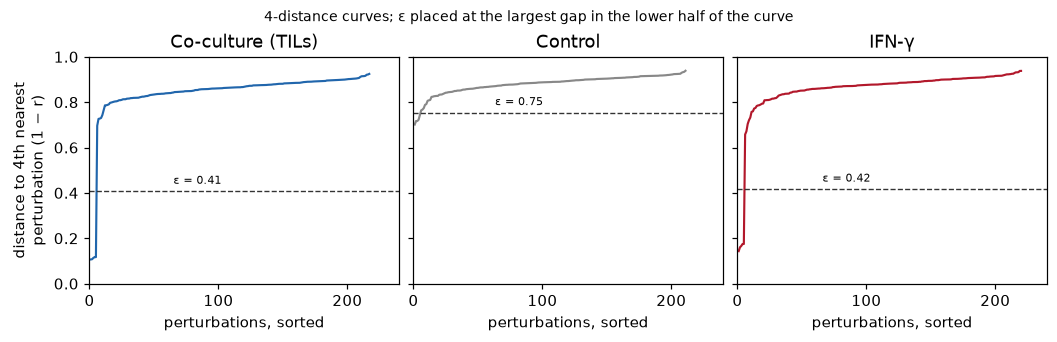

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.0), sharey=True, constrained_layout=True)
for ax, c in zip(axes, CONDS):
    kd = kdist(Dmat[c])
    ax.plot(np.arange(1, len(kd) + 1), kd, color=CCOL[c], lw=1.4)
    ax.axhline(EPS[c], color='#333333', ls='--', lw=0.9)
    ax.annotate('\u03b5 = %.2f' % EPS[c], xy=(len(kd) * 0.30, EPS[c]), xytext=(0, 5),
                textcoords='offset points', fontsize=7)
    ax.set_title(CONDLAB[c]); ax.set_xlabel('perturbations, sorted')
    ax.set_xlim(0, 240); ax.set_xticks([0, 100, 200]); ax.set_ylim(0, 1.0)
axes[0].set_ylabel('distance to 4th nearest\nperturbation (1 \u2212 r)')
fig.suptitle('4-distance curves; \u03b5 placed at the largest gap in the lower half of the curve', fontsize=9)
fig.savefig('figures/task2_kdistance.png', dpi=300)

**Figure 2.** 4-distance curves. Co-culture and IFN-γ each show a step of ≈ 0.5 in correlation
distance between the five lowest points and the rest; Control's largest gap is 0.022, i.e. the
curve is smooth and no density threshold separates a core from the bulk.

### 2.3 k-means and Leiden parameter diagnostics

The exploratory clustering notebook compared k-means solutions by silhouette and elbow
curves and swept Leiden resolution. Those diagnostics are retained here, but recomputed on
the filtered log2FC signatures and the same correlation-distance matrices used for scoring.
The k-means sweep is a sensitivity analysis: k = 8 remains fixed for the four partitional
methods so they are directly comparable. Leiden resolution is selected independently within
each condition by the highest finite silhouette, then held fixed during bootstrapping.

In [15]:
K_SWEEP = range(2, 16)
LEIDEN_RES_SWEEP = np.round(np.arange(0.1, 2.01, 0.1), 1)
LEIDEN_KNN = 10

def knn_igraph(Dm, n_neighbors=LEIDEN_KNN):
    # Weighted symmetric kNN graph on correlation distance. Unlike the exploratory notebook,
    # every condition is scored against its own Dm; no stale X_pca can leak between loops.
    edge_weight = {}
    positive = Dm[Dm > 0]
    scale = float(np.median(positive)) if positive.size else 1.0
    for i in range(len(Dm)):
        for j in np.argsort(Dm[i])[1:n_neighbors + 1]:
            edge = (min(i, int(j)), max(i, int(j)))
            edge_weight[edge] = max(edge_weight.get(edge, 0.0),
                                    float(np.exp(-Dm[i, j] / max(scale, 1e-12))))
    graph = ig.Graph(n=len(Dm), edges=list(edge_weight), directed=False)
    graph.es['weight'] = list(edge_weight.values())
    return graph

def leiden_labels(Dm, resolution, n_neighbors=LEIDEN_KNN):
    graph = knn_igraph(Dm, n_neighbors=n_neighbors)
    part = leidenalg.find_partition(
        graph, leidenalg.RBConfigurationVertexPartition, weights='weight',
        resolution_parameter=float(resolution), seed=123)
    return np.asarray(part.membership, dtype=int)

def safe_silhouette(Dm, lab):
    ncl = len(set(lab))
    return (silhouette_score(Dm, lab, metric='precomputed')
            if 1 < ncl < len(lab) else np.nan)

k_rows, leiden_rows = [], []
for c in CONDS:
    for k in K_SWEEP:
        km = KMeans(n_clusters=k, random_state=123, n_init=20).fit(sig[c].values)
        k_rows.append(dict(condition=c, k=k, inertia=km.inertia_,
                           silhouette=safe_silhouette(Dmat[c], km.labels_)))
    for res in LEIDEN_RES_SWEEP:
        lab = leiden_labels(Dmat[c], res)
        leiden_rows.append(dict(condition=c, resolution=res, n_clusters=len(set(lab)),
                                 silhouette=safe_silhouette(Dmat[c], lab)))

K_DIAG = pd.DataFrame(k_rows)
LEIDEN_DIAG = pd.DataFrame(leiden_rows)
LEIDEN_RES = {c: float(LEIDEN_DIAG[LEIDEN_DIAG.condition == c]
                               .sort_values(['silhouette', 'resolution'], ascending=[False, True])
                               .iloc[0].resolution) for c in CONDS}
BEST_K_SIL = {c: int(K_DIAG[K_DIAG.condition == c].sort_values('silhouette', ascending=False).iloc[0].k)
              for c in CONDS}
pd.DataFrame({'best_k_by_silhouette': BEST_K_SIL, 'selected_leiden_resolution': LEIDEN_RES})

,best_k_by_silhouette,selected_leiden_resolution
Co_culture,2,0.5
Control,2,0.4
IFNg,2,0.5


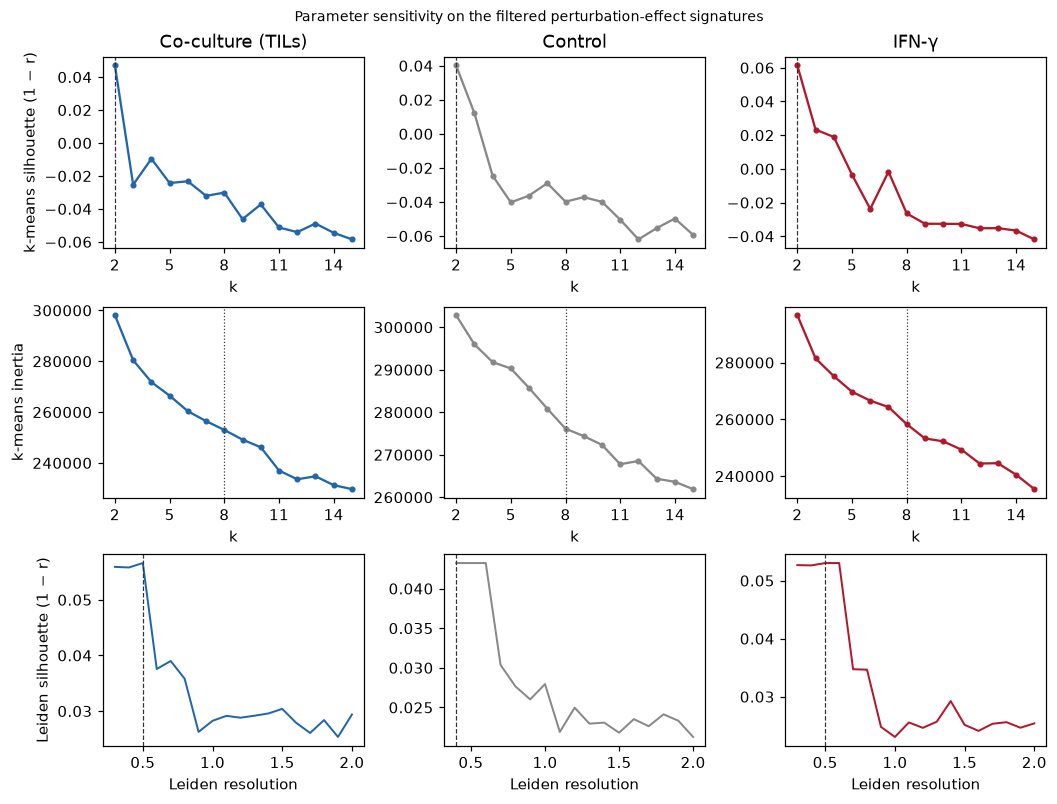

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(9.5, 7.2), constrained_layout=True)
for j, c in enumerate(CONDS):
    kd = K_DIAG[K_DIAG.condition == c]
    ld = LEIDEN_DIAG[LEIDEN_DIAG.condition == c]
    axes[0, j].plot(kd.k, kd.silhouette, marker='o', ms=3, color=CCOL[c])
    axes[0, j].axvline(BEST_K_SIL[c], color='#333333', ls='--', lw=0.8)
    axes[0, j].set_title(CONDLAB[c]); axes[0, j].set_xticks([2, 5, 8, 11, 14])
    axes[1, j].plot(kd.k, kd.inertia, marker='o', ms=3, color=CCOL[c])
    axes[1, j].axvline(8, color='#333333', ls=':', lw=0.8)
    axes[1, j].set_xticks([2, 5, 8, 11, 14])
    axes[2, j].plot(ld.resolution, ld.silhouette, color=CCOL[c], lw=1.3)
    axes[2, j].axvline(LEIDEN_RES[c], color='#333333', ls='--', lw=0.8)
    axes[2, j].set_xlabel('Leiden resolution')
axes[0, 0].set_ylabel('k-means silhouette (1 − r)')
axes[1, 0].set_ylabel('k-means inertia')
axes[2, 0].set_ylabel('Leiden silhouette (1 − r)')
for ax in axes[:2].ravel(): ax.set_xlabel('k')
fig.suptitle('Parameter sensitivity on the filtered perturbation-effect signatures', fontsize=9)
fig.savefig('figures/task2_parameter_diagnostics.png', dpi=300, bbox_inches='tight')
K_DIAG.to_csv('data/kmeans_parameter_diagnostics.csv', index=False)
LEIDEN_DIAG.to_csv('data/leiden_parameter_diagnostics.csv', index=False)

**Figure 3.** k-means silhouette and inertia across k = 2–15, plus the perturbation-level
Leiden resolution sweep. Dashed lines mark the best internal score; the dotted k = 8 line
marks the common partition size used for cross-method comparisons. Silhouette selects k = 2
in all three conditions; this is evidence for coarse structure, not a reason to conceal finer
forced partitions. Selected Leiden resolutions are 0.5 / 0.4 / 0.5 for Co-culture / Control /
IFN-γ and also yield two clusters in each point estimate.

### 2.4 Seven clusterings per condition

k = 8 for the partitional methods (three hierarchical linkages plus k-means) so their outputs
are directly comparable. DBSCAN and HDBSCAN choose their own number of groups and may label
points as noise (`-1`); Leiden uses the condition-specific resolution selected above.

In [17]:
METHODS = ['ward_euclid', 'average_corr', 'complete_corr', 'kmeans', 'leiden', 'dbscan', 'hdbscan']
K_PART, MIN_CLUSTER_SIZE, MIN_SAMPLES = 8, 3, 4

def cluster_all(Z, Dm, eps, leiden_res, K=K_PART):
    cond = squareform(Dm, checks=False)
    out = {
        'ward_euclid'  : fcluster(linkage(Z.values, method='ward'), K, criterion='maxclust'),
        'average_corr' : fcluster(linkage(cond, method='average'),  K, criterion='maxclust'),
        'complete_corr': fcluster(linkage(cond, method='complete'), K, criterion='maxclust'),
        'kmeans'       : KMeans(n_clusters=K, random_state=123, n_init=20).fit_predict(Z.values),
        'leiden'       : leiden_labels(Dm, leiden_res),
        'dbscan'       : DBSCAN(eps=eps, min_samples=MIN_SAMPLES, metric='precomputed').fit_predict(Dm),
        'hdbscan'      : HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, metric='precomputed',
                                 copy=True).fit_predict(Dm.astype(np.float64)),
    }
    return {k: pd.Series(v, index=Z.index) for k, v in out.items()}

labels = {c: cluster_all(sig[c], Dmat[c], EPS[c], LEIDEN_RES[c]) for c in CONDS}

pd.DataFrame([dict(condition=c, method=m,
                   n_clusters=len(set(s) - {-1}), n_noise=int((s == -1).sum()),
                   cluster_sizes=sorted(s[s != -1].value_counts().tolist(), reverse=True))
              for c in CONDS for m, s in labels[c].items()])

,condition,method,n_clusters,n_noise,cluster_sizes
0,Co_culture,ward_euclid,8,0,"[135, 71, 5, 2, 1, 1, 1, 1]"
1,Co_culture,average_corr,8,0,"[54, 53, 51, 25, 14, 9, 8, 3]"
2,Co_culture,complete_corr,8,0,"[36, 35, 29, 29, 28, 25, 18, 17]"
3,Co_culture,kmeans,8,0,"[98, 84, 19, 7, 5, 2, 1, 1]"
4,Co_culture,leiden,2,0,"[126, 91]"
5,Co_culture,dbscan,1,212,[5]
6,Co_culture,hdbscan,3,170,"[23, 17, 7]"
7,Control,ward_euclid,8,0,"[93, 83, 26, 4, 2, 1, 1, 1]"
8,Control,average_corr,8,0,"[55, 34, 32, 26, 23, 22, 14, 5]"
9,Control,complete_corr,8,0,"[38, 34, 25, 24, 23, 23, 22, 22]"


In [18]:
# membership of every non-singleton cluster found by the two density methods
for c in CONDS:
    for m in ['dbscan', 'hdbscan']:
        s = labels[c][m]
        for cl in sorted(set(s) - {-1}):
            mem = sorted(s.index[s == cl])
            print('%-11s %-8s cluster %-2s n=%2d  %s' % (c, m, cl, len(mem), ', '.join(mem)))

Co_culture  dbscan   cluster 0  n= 5  IFNGR1, IFNGR2, JAK1, JAK2, STAT1
Co_culture  hdbscan  cluster 0  n=23  ACTA2, CCR10, DLL3, GRN, HNRNPA1, IFNGR1, IFNGR2, IRF3, JAK1, JAK2, JMJD7, KCNN4, PPIA, RRS1, SCARB2, SMAD3, SOX4, STAT1, TM4SF1, TMEM173, TP53, TXNDC17, WBP2
Co_culture  hdbscan  cluster 1  n= 7  A2M, BZW2, CDK6, CDKN2B, GPNMB, MDH2, NPC1
Co_culture  hdbscan  cluster 2  n=17  ACSL3, BOLA2B, CTPS1, DNMT1, FKBP4, GSEC, MRPL47, MYC, PABPC1, PAICS, PET100, PUF60, RNASEH2A, SINHCAF, SMAD4, TPRKB, VDAC2
Control     dbscan   cluster 0  n=14  ACSL3, CCND1, CDK4, CDK6, CKS1B, CTPS1, HLA-F, PET100, PPIA, PYGB, SERPINE2, SINHCAF, TMED10, UQCRFS1
Control     hdbscan  cluster 0  n= 3  ITGA3, LGALS3BP, VAT1
Control     hdbscan  cluster 1  n= 3  CD274, SERPINA3, TAPBP
Control     hdbscan  cluster 2  n= 6  ACTA2, CDKN1A, CTSD, JAK1, TAPBPL, TXNDC17
Control     hdbscan  cluster 3  n=17  ACSL3, AGA, BOLA2B, BZW2, CCND1, CDK4, CDK6, CKS1B, CTPS1, HLA-F, MDH2, PET100, PPIA, PYGB, SERPINE2, SINHCA

DBSCAN's only cluster in Co-culture and in IFN-γ is exactly `IFNGR1, IFNGR2, JAK1, JAK2, STAT1`;
everything else is noise (212 and 215 targets). In Control the only cluster it finds instead
contains `CCND1, CDK4, CDK6, CKS1B` among 14 members and none of the five IFN-γ/JAK-STAT genes.

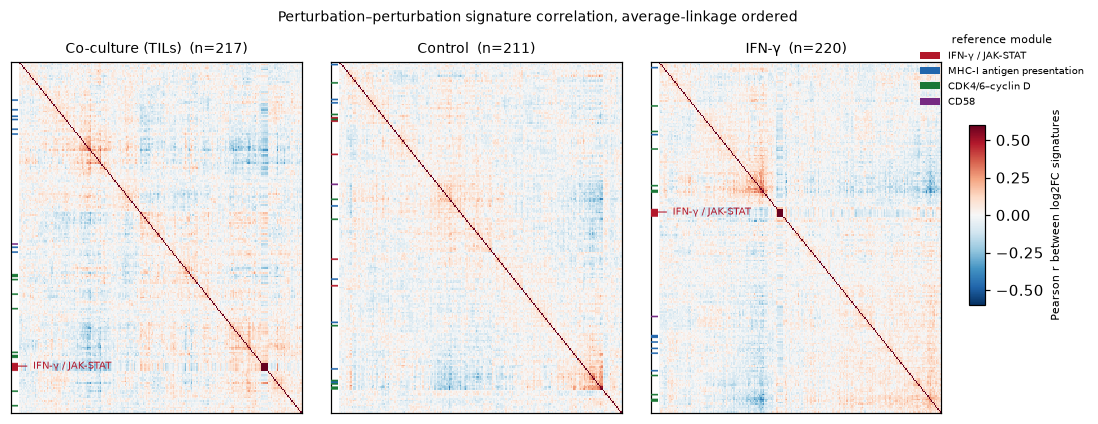

In [19]:
# correlation heatmap, average-linkage ordered, with reference modules as a colour strip
PAPER_CORE = json.load(open('data/pathway_labels_paper_core.json'))
MODCOL   = {'IFNG_JAK_STAT': '#b2182b', 'MHC_I_ANTIGEN_PRES': '#2166ac',
            'CDK4_6_CYCLIN_D': '#1b7837', 'CD58': '#762a83'}
MODSHORT = {'IFNG_JAK_STAT': 'IFN-γ / JAK-STAT', 'MHC_I_ANTIGEN_PRES': 'MHC-I antigen presentation',
            'CDK4_6_CYCLIN_D': 'CDK4/6–cyclin D', 'CD58': 'CD58'}

fig = plt.figure(figsize=(10.2, 4.1))
gs  = fig.add_gridspec(1, 3, wspace=0.10, left=0.03, right=0.86, top=0.84, bottom=0.06)
for j, c in enumerate(CONDS):
    ax = fig.add_subplot(gs[0, j])
    o  = leaves_list(linkage(squareform(Dmat[c], checks=False), method='average'))
    names = [R[c].index[i] for i in o]
    im = ax.imshow(R[c].values[np.ix_(o, o)], cmap='RdBu_r', vmin=-0.6, vmax=0.6,
                   interpolation='nearest', extent=[0, len(names), len(names), 0])
    ax.set_xticks([]); ax.set_yticks([])
    strip = np.zeros((len(names), 1, 4)); strip[:] = (1, 1, 1, 0)
    for i, g in enumerate(names):
        for mod, mem in PAPER_CORE.items():
            if g in mem:
                strip[i, 0] = mpl.colors.to_rgba(MODCOL[mod])
    ax.imshow(strip, extent=[-6, -1, len(names), 0], aspect='auto', zorder=5)
    ax.set_xlim(-6.5, len(names)); ax.set_ylim(len(names), 0)
    js = [i for i, g in enumerate(names) if g in PAPER_CORE['IFNG_JAK_STAT']]
    if js and (max(js) - min(js)) <= 6:
        ax.annotate('IFN-γ / JAK-STAT', xy=(-6, (min(js) + max(js)) / 2), xytext=(14, 0),
                    textcoords='offset points', fontsize=6.5, va='center', color=MODCOL['IFNG_JAK_STAT'],
                    arrowprops=dict(arrowstyle='-', lw=0.7, color=MODCOL['IFNG_JAK_STAT']), zorder=6)
    ax.set_title('%s  (n=%d)' % (CONDLAB[c], len(names)), fontsize=9)
cax = fig.add_axes([0.885, 0.30, 0.014, 0.40])
fig.colorbar(im, cax=cax).set_label('Pearson r between log2FC signatures', fontsize=7)
fig.legend(handles=[mpl.patches.Patch(fc=MODCOL[m], label=MODSHORT[m]) for m in PAPER_CORE],
           loc='lower right', bbox_to_anchor=(0.995, 0.72), frameon=False, fontsize=6.5,
           title='reference module', title_fontsize=7)
fig.suptitle('Perturbation–perturbation signature correlation, average-linkage ordered', fontsize=9, y=0.955)
fig.savefig('figures/task2_correlation_heatmap.png', dpi=300, bbox_inches='tight')

**Figure 4.** Signature correlation matrices, rows and columns ordered by average-linkage
dendrogram on 1 − r. Colour strip at the left of each panel marks reference-module membership
(Section 3). Diverging scale centred at r = 0.

## 3 Reference pathway labels

Ground truth for scoring is assembled from two sources, both recorded in the `source` column of
`data/pathway_labels.csv`:

* **`Frangieh2021_paper_module`** — the three programmes the paper discusses (IFN-γ–JAK/STAT
  signalling, MHC-I antigen presentation, CD58) plus the CDK4/6–cyclin D axis, entered manually
  from the publication.
* **`Reactome`** — pathway membership fetched per target from the Reactome ContentService HGNC
  mapping endpoint, then reduced to pathways with ≥ 5 members among the 248 targets.

Three targets present in a Reactome group (`UBA52`, `UBC`, `PPIA`) were removed: they belong to
dozens of pathways each, so their membership reflects annotation promiscuity rather than a
shared perturbation response.

**The labels cover 56 of 248 targets.** They are an incomplete reference, so ARI computed
against them is a lower bound: a cluster of genuinely co-functional targets that happen to be
unlabelled scores as disagreement.

In [20]:
# Reference labels are cached; the fetch that produced them is in section 3.1 below.
lab_df = pd.read_csv('data/pathway_labels.csv')
lab_df.groupby(['source', 'label']).perturbation.agg(n='size', members=lambda x: ', '.join(sorted(x)))

n                                            members
source                    label                                                                        
Frangieh2021_paper_module CD58                     1                                               CD58
                          CDK4_6_CYCLIN_D         10  CCND1, CCND2, CDK4, CDK6, CDKN1A, CDKN2A, CDKN...
                          IFNG_JAK_STAT            5                  IFNGR1, IFNGR2, JAK1, JAK2, STAT1
                          MHC_I_ANTIGEN_PRES       8  B2M, HLA-A, HLA-B, HLA-C, HLA-E, HLA-F, HLA-H,...
Reactome                  IFNG_JAK_STAT            7    CD44, HLA-DRB5, IRF3, IRF4, MT2A, SP100, TRIM22
                          LYSOSOMAL_CATHEPSIN      5                       CTSA, CTSB, CTSD, CTSL, CTSO
                          MITO_RESPIRATION_TCA     8  CHCHD2, IDH2, MDH2, NDUFA13, SLC25A13, TIMM50,...
                          MRNA_SPLICING            7  HNRNPA1, HNRNPC, PUF60, SNRPE, SNRPF, SNRPG, UBL5
                          TRANSLATION_INITIATION   5                EIF2S3, EIF3K, EIF4A1, PABPC1, RPSA

In [21]:
LAB_FULL   = dict(zip(lab_df.perturbation, lab_df.label))
PAPER_ONLY = {g: l for l, v in PAPER_CORE.items() for g in v}
print('labelled targets: %d of 248 (%d in the paper modules)' % (len(LAB_FULL), len(PAPER_ONLY)))

labelled targets: 56 of 248 (24 in the paper modules)


### 3.1 How the Reactome labels were fetched

Run to regenerate; the result is already in `data/pathway_labels.csv`.

In [22]:
FETCH_REACTOME = False   # set True to re-fetch (248 sequential requests, ~2 min)

if FETCH_REACTOME:
    import requests
    from collections import Counter, defaultdict
    sess = requests.Session()
    react = {}
    for s in lf['Co_culture'].index:
        r = sess.get(f'https://reactome.org/ContentService/data/mapping/HGNC/{s}/pathways?species=9606',
                     timeout=30)
        react[s] = [(p['stId'], p['displayName']) for p in r.json()] if r.status_code == 200 else []
    members = defaultdict(set)
    for g, pws in react.items():
        for stid, name in pws:
            members[(stid, name)].add(g)
    big = {k: v for k, v in members.items() if len(v) >= 5}
    print('%d Reactome pathways with >=5 of the 248 targets' % len(big))

## 4 Scoring

Four measures per method and condition:

* **ARI / AMI vs the full 56-target reference** — external agreement over all labels.
* **ARI vs the paper modules only** (24 targets) — the labels the paper's findings concern.
* **Silhouette on correlation distance**, noise points excluded — internal cohesion.
* **Bootstrap stability** — cells are resampled with replacement *within each perturbation
  group*, the log2FC matrix, gene selection and clustering are recomputed, and the mean pairwise
  ARI across 25 replicates is reported. This propagates cell-sampling noise, which is the
  dominant uncertainty in a pseudo-bulk signature.

Stability alone is a misleading criterion for a density method: DBSCAN reproduces the same
single cluster in every replicate and so scores 1.000 in the two immune conditions by being
degenerate. A fifth measure is therefore reported alongside — **core recovery rate**, the
fraction of replicates in which all five IFN-γ/JAK-STAT targets land together in one non-noise
cluster.

In [23]:
# The bootstrap needs cell-level counts, which live in the raw gene-major store.
# src/task2_bootstrap.py holds the loader; its group means reproduce the cached
# log2FC to 1.6e-5, which is the licence for using it to resample.
RUN_BOOTSTRAP = False   # True rebuilds every method; missing methods are refreshed automatically.
NB = 25

BOOT_FILE = 'data/task2_bootstrap_labels.pkl'
if RUN_BOOTSTRAP or not os.path.isfile(BOOT_FILE):
    boot = {c: {m: [] for m in METHODS} for c in CONDS}
    methods_to_run = list(METHODS)
else:
    _b = pd.read_pickle(BOOT_FILE)
    boot, NB = _b['boot'], _b['NB']
    methods_to_run = [m for m in METHODS
                      if any(m not in boot.get(c, {}) or len(boot[c][m]) != NB for c in CONDS)]

if methods_to_run:
    import sys; sys.path.insert(0, 'src')
    import task2_bootstrap as tb
    UNION = sorted(set().union(*[set(gsel[c]) for c in CONDS]))
    celldata = tb.load_cells(UNION, list(lf['Co_culture'].columns))

    def signature_from_group_means(gm, c):
        L = ((gm.drop(index='__CONTROL__') - gm.loc['__CONTROL__']) / np.log(2)).loc[keep[c], gsel[c]]
        Z = (L - L.mean(axis=0)) / L.std(axis=0).replace(0, np.nan)
        return Z.dropna(axis=1)

    for c in CONDS:
        boot.setdefault(c, {})
        for m in methods_to_run:
            boot[c][m] = []
        for b in range(NB):
            rng = np.random.default_rng(1000 + b)
            Zb = signature_from_group_means(tb.group_mean(celldata[c], rng=rng), c)
            Db = 1.0 - np.corrcoef(Zb.values); np.fill_diagonal(Db, 0.0)
            clustered = cluster_all(Zb, Db, EPS[c], LEIDEN_RES[c])
            for m in methods_to_run:
                boot[c][m].append(clustered[m])
        print(c, 'refreshed:', ', '.join(methods_to_run))
    pd.to_pickle(dict(boot=boot, eps_used=EPS, leiden_resolution=LEIDEN_RES, NB=NB), BOOT_FILE)
print('%d bootstrap replicates per condition x method; refreshed %s' %
      (NB, methods_to_run or 'none (cache complete)'))

25 bootstrap replicates per condition x method; refreshed none (cache complete)


In [24]:
from itertools import combinations

STAB = []
for c in CONDS:
    for m in METHODS:
        Ls = boot[c][m]
        STAB.append(dict(condition=c, method=m,
            stability_mean_pairwise_ari=np.mean([ARI(Ls[i].values, Ls[j].values)
                                                 for i, j in combinations(range(NB), 2)]),
            stability_vs_point_estimate=np.mean([ARI(labels[c][m].values, L.values) for L in Ls]),
            boot_mean_n_noise=float(np.mean([(L == -1).sum() for L in Ls])),
            boot_mean_n_clusters=float(np.mean([len(set(L) - {-1}) for L in Ls]))))
STAB = pd.DataFrame(STAB)

# core recovery: all five IFN-\u03b3/JAK-STAT targets in ONE non-noise cluster
core_rate = {}
for c in CONDS:
    for m in METHODS:
        hits = []
        for L in boot[c][m]:
            v = L.reindex(JS).dropna()
            hits.append(float(len(v) == 5 and v.nunique() == 1 and v.iloc[0] != -1))
        core_rate[(c, m)] = float(np.mean(hits))

STAB['core_recovery_rate'] = [core_rate[(r.condition, r.method)] for r in STAB.itertuples()]
STAB.round(3)

,condition,method,stability_mean_pairwise_ari,stability_vs_point_estimate,boot_mean_n_noise,boot_mean_n_clusters,core_recovery_rate
0,Co_culture,ward_euclid,0.232,0.253,0.00,8.00,1.00
1,Co_culture,average_corr,0.112,0.173,0.00,8.00,1.00
2,Co_culture,complete_corr,0.063,0.099,0.00,8.00,1.00
3,Co_culture,kmeans,0.166,0.232,0.00,8.00,1.00
4,Co_culture,leiden,0.194,0.323,0.00,2.00,1.00
5,Co_culture,dbscan,1.000,1.000,212.00,1.00,1.00
6,Co_culture,hdbscan,0.311,0.406,173.32,3.52,1.00
7,Control,ward_euclid,0.076,0.104,0.00,8.00,0.04
8,Control,average_corr,0.087,0.149,0.00,8.00,0.00
9,Control,complete_corr,0.046,0.075,0.00,8.00,0.00


In [25]:
def external_scores(s, ref, exclude_noise=False):
    ss = s[s != -1] if exclude_noise else s
    idx = [g for g in ss.index if g in ref]
    if len(idx) < 3 or len(set(ss.loc[idx])) < 2:
        return dict(n_labelled=len(idx), ari=np.nan, ami=np.nan)
    y = [ref[g] for g in idx]
    return dict(n_labelled=len(idx), ari=ARI(y, ss.loc[idx].values), ami=AMI(y, ss.loc[idx].values))

rows = []
for c in CONDS:
    for m, s in labels[c].items():
        nz = s.values != -1
        sil = (silhouette_score(Dmat[c][np.ix_(nz, nz)], s.values[nz], metric='precomputed')
               if nz.sum() > 2 and len(set(s.values[nz])) > 1 else np.nan)
        f, p, fn = (external_scores(s, LAB_FULL), external_scores(s, PAPER_ONLY),
                    external_scores(s, LAB_FULL, exclude_noise=True))
        rows.append(dict(condition=c, method=m,
                         n_clusters=len(set(s) - {-1}), n_noise=int((s == -1).sum()), silhouette=sil,
                         ari_full=f['ari'], ami_full=f['ami'], n_lab_full=f['n_labelled'],
                         ari_paper=p['ari'], ami_paper=p['ami'], n_paper=p['n_labelled'],
                         ari_full_nonoise=fn['ari'], n_full_nonoise=fn['n_labelled']))

COMP = pd.DataFrame(rows).merge(STAB, on=['condition', 'method'])
COMP['composite_paper_x_stability'] = COMP.ari_paper * COMP.stability_mean_pairwise_ari
COMP['eps_used'] = [EPS[c] for c in COMP.condition]
COMP.to_csv('data/clustering_comparison.csv', index=False)
COMP[['condition', 'method', 'ari_full', 'ami_full', 'ari_paper', 'silhouette',
      'stability_mean_pairwise_ari', 'core_recovery_rate', 'n_clusters', 'n_noise']].round(3)

,condition,method,ari_full,ami_full,ari_paper,silhouette,stability_mean_pairwise_ari,core_recovery_rate,n_clusters,n_noise
0,Co_culture,ward_euclid,0.071,0.124,0.544,-0.050,0.232,1.00,8,0
1,Co_culture,average_corr,0.117,0.174,0.198,0.017,0.112,1.00,8,0
2,Co_culture,complete_corr,0.114,0.146,0.285,0.018,0.063,1.00,8,0
3,Co_culture,kmeans,0.059,0.105,0.463,-0.030,0.166,1.00,8,0
4,Co_culture,leiden,0.058,0.035,0.181,0.057,0.194,1.00,2,0
5,Co_culture,dbscan,-0.003,0.086,0.368,NaN,1.000,1.00,1,212
6,Co_culture,hdbscan,0.038,0.167,0.322,0.129,0.311,1.00,3,170
7,Control,ward_euclid,0.011,0.035,-0.041,-0.035,0.076,0.04,8,0
8,Control,average_corr,-0.007,-0.006,0.003,0.023,0.087,0.00,8,0
9,Control,complete_corr,0.036,0.051,-0.009,0.011,0.046,0.00,8,0


Reading the table:

* `ari_full` never exceeds 0.12 in any condition or method. Against the paper modules only
  (`ari_paper`) it reaches 0.544 in Co-culture and 0.373 in IFN-γ, but stays between −0.06 and
  0.004 in Control.
* The five-gene IFN-γ/JAK-STAT core is recovered in every bootstrap by all seven methods in
  Co-culture and IFN-γ. Control recovery is 0–20 %, including 20 % for Leiden.
* Silhouette is negative for Ward and k-means (they cut a continuum), 0.043–0.057 for the
  internally selected two-cluster Leiden solutions, and 0.12–0.19 for HDBSCAN, which keeps
  only the dense parts.
* Leiden's mean pairwise bootstrap ARI is 0.194 / 0.139 / 0.174 for Co-culture / Control /
  IFN-γ; its coarse partition is moderately stable but agrees less well with the paper modules
  than Ward or k-means in the immune conditions.
* DBSCAN's stability of 1.000 in the two immune conditions reflects it returning the identical
  single 5-member cluster in all 25 replicates.

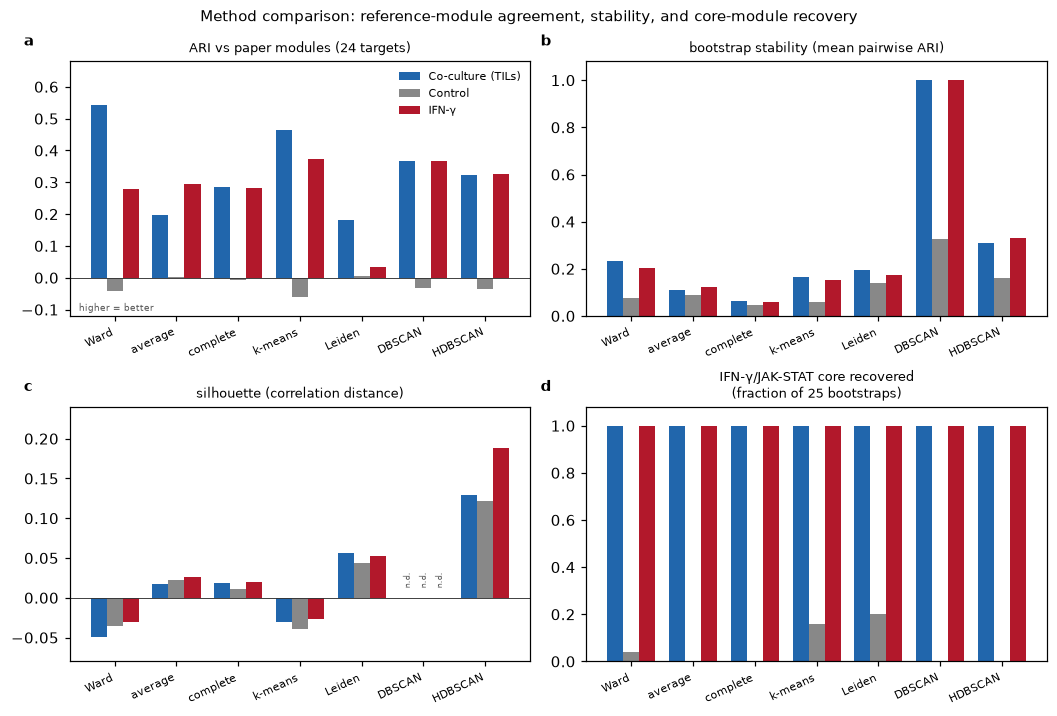

In [26]:
MSHORT = {'ward_euclid': 'Ward', 'average_corr': 'average', 'complete_corr': 'complete',
          'kmeans': 'k-means', 'leiden': 'Leiden', 'dbscan': 'DBSCAN', 'hdbscan': 'HDBSCAN'}
x, w = np.arange(len(METHODS)), 0.26
panels = [('ari_paper', 'ARI vs paper modules (24 targets)'),
          ('stability_mean_pairwise_ari', 'bootstrap stability (mean pairwise ARI)'),
          ('silhouette', 'silhouette (correlation distance)'),
          (None, 'IFN-\u03b3/JAK-STAT core recovered\n(fraction of 25 bootstraps)')]

fig, axes = plt.subplots(2, 2, figsize=(9.5, 6.4), constrained_layout=True)
axes = axes.ravel()
for ax, (col, title) in zip(axes, panels):
    for k, c in enumerate(CONDS):
        vals = (np.array([core_rate[(c, m)] for m in METHODS], dtype=float) if col is None
                else np.array([float(COMP[(COMP.condition == c) & (COMP.method == m)][col].iloc[0])
                               for m in METHODS], dtype=float))
        ax.bar(x + (k - 1) * w, np.nan_to_num(vals, nan=0.0), w, color=CCOL[c],
               label=CONDLAB[c] if ax is axes[0] else None)
        for xi, v in zip(x + (k - 1) * w, vals):
            if np.isnan(v):
                ax.annotate('n.d.', xy=(xi, 0.012), ha='center', va='bottom', fontsize=5.5,
                            rotation=90, color='#555555')
    ax.set_xticks(x); ax.set_xticklabels([MSHORT[m] for m in METHODS], rotation=25, ha='right', fontsize=7)
    ax.set_title(title, fontsize=8.5); ax.axhline(0, color='#333333', lw=0.6)
axes[0].set_ylim(-0.12, 0.68); axes[0].set_yticks([-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
axes[1].set_ylim(0, 1.08);     axes[1].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
axes[2].set_ylim(-0.08, 0.24); axes[2].set_yticks([-0.05, 0, 0.05, 0.10, 0.15, 0.20])
axes[3].set_ylim(0, 1.08);     axes[3].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
axes[0].legend(frameon=False, fontsize=7, loc='upper right')
axes[0].annotate('higher = better', xy=(0.02, 0.02), xycoords='axes fraction', fontsize=6, color='#555555')
for a_, l in zip(axes, 'abcd'):
    a_.annotate(l, xy=(0, 1), xycoords='axes fraction', xytext=(-30, 8), textcoords='offset points',
                fontweight='bold', fontsize=10, va='bottom')
fig.suptitle('Method comparison: reference-module agreement, stability, and core-module recovery', fontsize=9.5)
fig.savefig('figures/task2_method_comparison.png', dpi=300, bbox_inches='tight')

**Figure 5.** Method comparison. (a) ARI against the four paper modules, restricted to the 24
labelled targets. (b) Mean pairwise ARI across 25 bootstrap replicates. (c) Silhouette on
correlation distance, noise points excluded; `n.d.` where a single cluster makes it undefined.
(d) Fraction of replicates in which all five IFN-γ/JAK-STAT targets share one non-noise cluster.

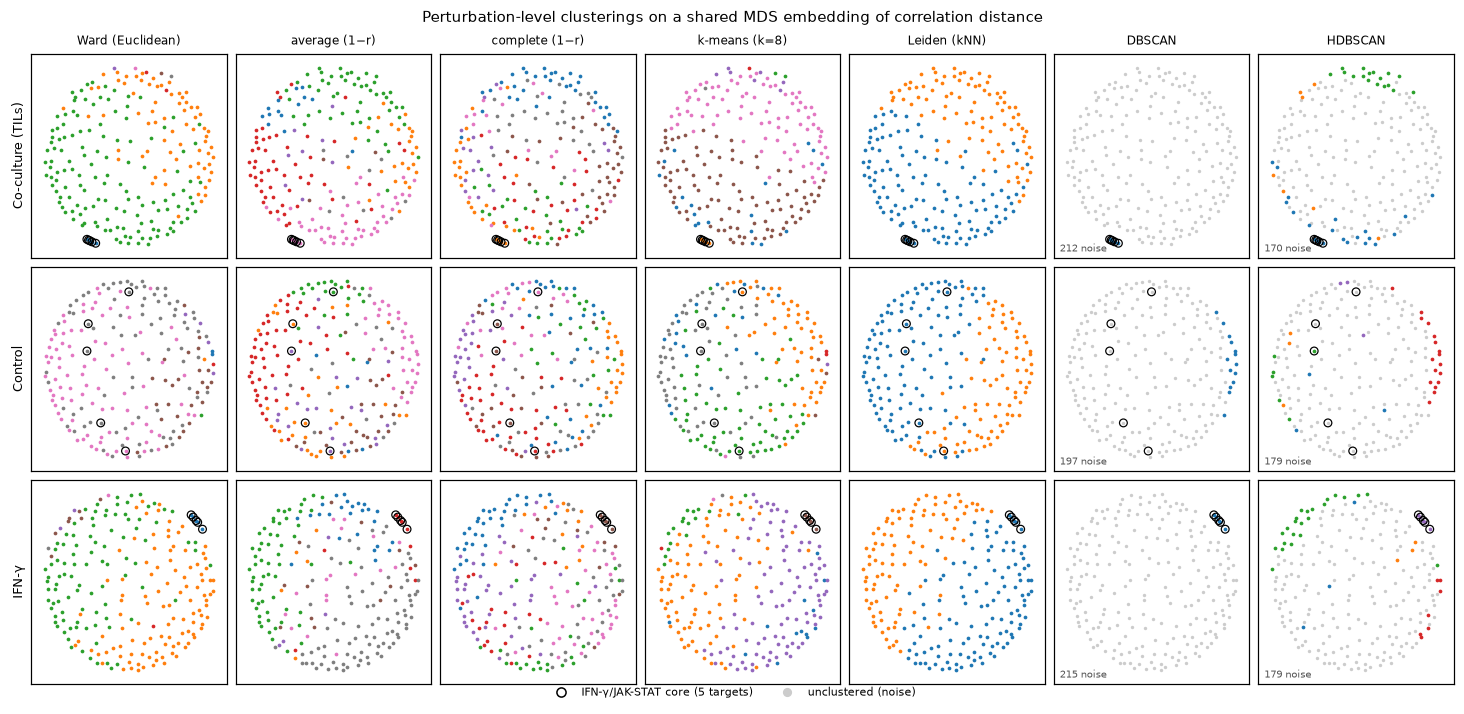

In [27]:
EMB = {c: MDS(n_components=2, metric='precomputed', random_state=7, init='random',
              normalized_stress='auto', n_init=4).fit_transform(Dmat[c]) for c in CONDS}

MLAB = {'ward_euclid': 'Ward (Euclidean)', 'average_corr': 'average (1\u2212r)',
        'complete_corr': 'complete (1\u2212r)', 'kmeans': 'k-means (k=8)', 'leiden': 'Leiden (kNN)',
        'dbscan': 'DBSCAN', 'hdbscan': 'HDBSCAN'}

fig, axes = plt.subplots(3, len(METHODS), figsize=(13.2, 6.2), constrained_layout=True)
for i, c in enumerate(CONDS):
    E = EMB[c]
    for j, m in enumerate(METHODS):
        ax = axes[i, j]; s = labels[c][m].values
        noise = s == -1
        ax.scatter(E[noise, 0], E[noise, 1], s=5, c='#cccccc', lw=0)
        cmap = plt.get_cmap('tab10')
        for k, cl in enumerate([v for v in sorted(set(s)) if v != -1]):
            mm = s == cl
            ax.scatter(E[mm, 0], E[mm, 1], s=6, color=cmap(k % 10), lw=0)
        js = [labels[c][m].index.get_loc(g) for g in JS if g in labels[c][m].index]
        ax.scatter(E[js, 0], E[js, 1], s=26, facecolors='none', edgecolors='black', lw=0.8, zorder=5)
        ax.set_xticks([]); ax.set_yticks([]); ax.margins(0.08)
        if i == 0: ax.set_title(MLAB[m], fontsize=8)
        if j == 0: ax.set_ylabel(CONDLAB[c], fontsize=8.5)
        if m in ('dbscan', 'hdbscan'):
            ax.annotate('%d noise' % noise.sum(), xy=(0.03, 0.03), xycoords='axes fraction',
                        fontsize=6.5, color='#555555')
fig.legend(handles=[plt.Line2D([], [], marker='o', ls='', mfc='none', mec='black', ms=6,
                               label='IFN-\u03b3/JAK-STAT core (5 targets)'),
                    plt.Line2D([], [], marker='o', ls='', color='#cccccc', ms=5,
                               label='unclustered (noise)')],
           loc='lower center', ncol=2, frameon=False, fontsize=7.5, bbox_to_anchor=(0.5, -0.03))
fig.suptitle('Perturbation-level clusterings on a shared MDS embedding of correlation distance', fontsize=9.5)
fig.savefig('figures/task2_method_embeddings.png', dpi=300, bbox_inches='tight')

**Figure 6.** All seven clusterings per condition, drawn on the same 2-D MDS embedding of the
correlation-distance matrix within each row so that colour differences are method differences,
not layout differences. Grey = noise. The MDS layout is a projection of a high-dimensional
distance matrix; between-point distances in the plane are approximate.

## 5 Factual observations

### 5.1 Module recovery per method and condition

In [28]:
def module_recovery(c, m):
    s = labels[c][m]
    rows = []
    for mod, mem in PAPER_CORE.items():
        mem = [g for g in mem if g in s.index]
        if not mem:
            continue
        best = max(((cl, len(set(s.index[s == cl]) & set(mem)) / len(set(s.index[s == cl]) | set(mem)),
                     len(set(s.index[s == cl]) & set(mem)), int((s == cl).sum()))
                    for cl in sorted(set(s) - {-1})), key=lambda t: (t[1], t[2]), default=(None, 0, 0, 0))
        rows.append(dict(condition=c, method=m, module=mod, n_members_present=len(mem),
                         best_cluster=best[0], jaccard=round(best[1], 3),
                         n_overlap=best[2], cluster_size=best[3],
                         n_noise_members=int((s.reindex(mem) == -1).sum())))
    return rows

MR = pd.DataFrame([r for c in CONDS for m in METHODS for r in module_recovery(c, m)])
MR.to_csv('data/module_recovery.csv', index=False)
MR.pivot_table(index=['module', 'method'], columns='condition', values='jaccard')

condition                         Co_culture  Control   IFNg
module             method                                   
CD58               average_corr        0.019    0.018  0.011
                   complete_corr       0.028    0.040  0.043
                   dbscan              0.000    0.000  0.000
                   hdbscan             0.000    0.000  0.000
                   kmeans              0.012    0.016  0.012
                   leiden              0.011    0.008  0.008
                   ward_euclid         0.007    0.011  0.010
CDK4_6_CYCLIN_D    average_corr        0.070    0.100  0.077
                   complete_corr       0.118    0.138  0.098
                   dbscan              0.000    0.200  0.000
                   hdbscan             0.133    0.174  0.133
                   kmeans              0.080    0.200  0.150
                   leiden              0.062    0.066  0.059
                   ward_euclid         0.074    0.200  0.200
IFNG_JAK_STAT      average_corr        0.098    0.077  0.500
                   complete_corr       0.172    0.120  0.333
                   dbscan              1.000    0.000  1.000
                   hdbscan             0.217    0.100  1.000
                   kmeans              1.000    0.047  1.000
                   leiden              0.040    0.032  0.041
                   ward_euclid         1.000    0.048  1.000
MHC_I_ANTIGEN_PRES average_corr        0.138    0.083  0.067
                   complete_corr       0.128    0.069  0.065
                   dbscan              0.000    0.048  0.000
                   hdbscan             0.000    0.100  0.000
                   kmeans              0.070    0.049  0.060
                   leiden              0.065    0.056  0.048
                   ward_euclid         0.068    0.062  0.056

In [29]:
# Which targets are called noise by the density methods, and how large are their effects?
eff = []
for c in CONDS:
    L, S = lf[c].loc[keep[c], gsel[c]].values, se[c].loc[keep[c], gsel[c]].values
    eff.append(pd.DataFrame({'perturbation': keep[c], 'condition': c,
                             'n_cells': ncells[c].loc[keep[c]].values,
                             'n_genes_z_gt3': (np.abs(L / S) > 3).sum(axis=1),
                             'mean_abs_log2fc': np.abs(L).mean(axis=1)}))
EFF = pd.concat(eff, ignore_index=True)

NT = pd.DataFrame({(c, m): (labels[c][m] == -1).astype(float)
                   for c in CONDS for m in ['dbscan', 'hdbscan']}).dropna()
noise_count = NT.sum(axis=1)          # 0..6 across 3 conditions x 2 density methods
E = EFF.pivot_table(index='perturbation', columns='condition', values='n_genes_z_gt3')
sub = pd.DataFrame({'noise_count': noise_count}).join(E).dropna()

pd.DataFrame({'n_targets': sub.groupby('noise_count').size(),
              **{'median_n_genes_z>3_' + c: sub.groupby('noise_count')[c].median() for c in CONDS}})

,n_targets,median_n_genes_z>3_Co_culture,median_n_genes_z>3_Control,median_n_genes_z>3_IFNg
noise_count,,,,
1.0,1,604.0,132.0,525.0
2.0,9,109.0,54.0,127.0
3.0,6,58.0,54.5,47.0
4.0,15,31.0,59.0,60.0
5.0,45,33.0,60.0,53.0
6.0,134,25.0,57.5,51.0


Targets never called noise (`noise_count` ≤ 1) have a median of several hundred genes at
|log2FC|/SE > 3; targets called noise by both density methods in all three conditions have a
median of 25–58. The noise label tracks measured effect size.

Note the confound: `n_genes_z_gt3` depends on the number of cells behind each row, and the
correlation between `n_cells` and `n_genes_z_gt3` is positive in all three conditions. Low
statistical power and small biological effect are not separated by this measure.

In [30]:
sub.groupby('noise_count').size().rename('n_targets').to_frame().join(
    EFF.pivot_table(index='perturbation', columns='condition', values='n_cells')
       .join(pd.DataFrame({'noise_count': noise_count})).groupby('noise_count').median().round(0)
)

,n_targets,Co_culture,Control,IFNg
noise_count,,,,
1.0,1,356.0,134.0,224.0
2.0,9,104.0,71.0,111.0
3.0,6,126.0,99.0,166.0
4.0,15,182.0,130.0,195.0
5.0,45,185.0,124.0,206.0
6.0,134,193.0,126.0,211.0


In [31]:
print('never noise (0 of 6): ', ', '.join(sorted(sub.index[sub.noise_count == 0])))
print()
print('n targets by noise_count:', dict(sub.groupby('noise_count').size()))
print()
print('correlation n_cells vs n_genes_z_gt3:',
      {c: round(float(EFF[EFF.condition == c][['n_cells', 'n_genes_z_gt3']].corr().iloc[0, 1]), 3)
       for c in CONDS})

never noise (0 of 6):  

n targets by noise_count: {1.0: np.int64(1), 2.0: np.int64(9), 3.0: np.int64(6), 4.0: np.int64(15), 5.0: np.int64(45), 6.0: np.int64(134)}

correlation n_cells vs n_genes_z_gt3: {'Co_culture': 0.441, 'Control': 0.309, 'IFNg': 0.179}


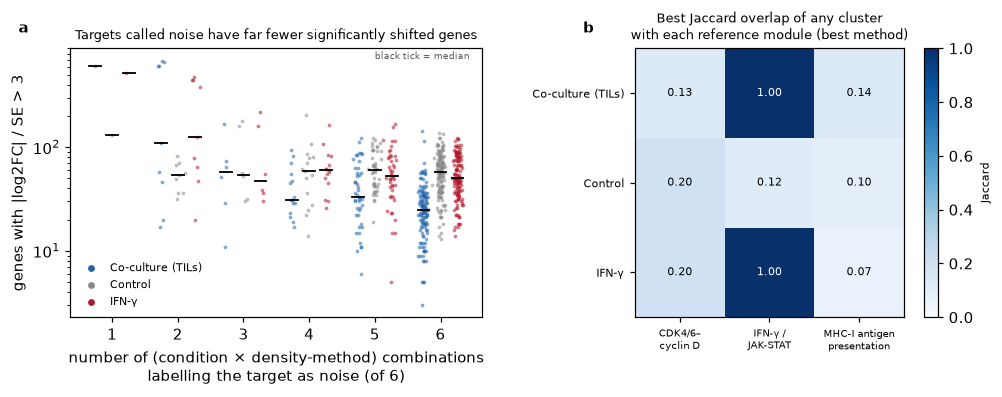

In [32]:
MODSHORT2 = {'IFNG_JAK_STAT': 'IFN-\u03b3 /\nJAK-STAT', 'MHC_I_ANTIGEN_PRES': 'MHC-I antigen\npresentation',
             'CDK4_6_CYCLIN_D': 'CDK4/6\u2013\ncyclin D', 'CD58': 'CD58'}

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.5), constrained_layout=True)

ax = axes[0]
jit = np.random.default_rng(0)
for k, c in enumerate(CONDS):
    for n in range(1, 7):
        v = sub[sub.noise_count == n][c].values
        if len(v) == 0:
            continue
        p = n + (k - 1) * 0.26
        ax.scatter(np.full(len(v), p) + jit.normal(0, 0.035, len(v)), v, s=6,
                   color=CCOL[c], alpha=0.55, lw=0)
        ax.plot([p - 0.09, p + 0.09], [np.median(v)] * 2, color='black', lw=1.2, zorder=5)
    ax.scatter([], [], s=12, color=CCOL[c], label=CONDLAB[c])
ax.set_yscale('log'); ax.set_xticks(range(1, 7))
ax.set_xlabel('number of (condition \u00d7 density-method) combinations\nlabelling the target as noise (of 6)')
ax.set_ylabel('genes with |log2FC| / SE > 3')
ax.legend(frameon=False, fontsize=7, loc='lower left')
ax.annotate('black tick = median', xy=(0.97, 0.96), xycoords='axes fraction', ha='right',
            fontsize=6, color='#555555')
ax.set_title('Targets called noise have far fewer significantly shifted genes', fontsize=8.5)

ax = axes[1]
mrc = MR[MR.module != 'CD58'].pivot_table(index='condition', columns='module', values='jaccard', aggfunc='max')
im = ax.imshow(mrc.values, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(mrc.shape[1]))
ax.set_xticklabels([MODSHORT2[m] for m in mrc.columns], rotation=0, ha='center', fontsize=6.5)
ax.set_yticks(range(len(mrc))); ax.set_yticklabels([CONDLAB[c] for c in mrc.index], fontsize=7.5)
for i in range(mrc.shape[0]):
    for j in range(mrc.shape[1]):
        v = mrc.values[i, j]
        ax.annotate('%.2f' % v, xy=(j, i), ha='center', va='center', fontsize=7,
                    color='white' if v > 0.5 else 'black')
ax.set_title('Best Jaccard overlap of any cluster\nwith each reference module (best method)', fontsize=8.5)
fig.colorbar(im, ax=ax, fraction=0.045).set_label('Jaccard', fontsize=7)
for a_, l in zip(axes, 'ab'):
    a_.annotate(l, xy=(0, 1), xycoords='axes fraction', xytext=(-34, 8), textcoords='offset points',
                fontweight='bold', fontsize=10, va='bottom')
fig.savefig('figures/task2_noise_and_module_recovery.png', dpi=300, bbox_inches='tight')

**Figure 7.** (a) Number of genes shifted at |log2FC|/SE > 3 per target, against how often the
two density methods called that target noise (188 targets present in all three conditions).
Log y axis. (b) Best Jaccard overlap between any single cluster and each reference module, taken
over the seven methods. CD58 is a one-member module and is omitted from (b).

### 5.2 Cluster membership in the chosen clustering

In [33]:
RECOMMENDED = ('Co_culture', 'ward_euclid')
ALT_FOR_TASK3 = ('Co_culture', 'hdbscan')

s = labels[RECOMMENDED[0]][RECOMMENDED[1]]
pd.DataFrame([dict(cluster=int(cl), n=int((s == cl).sum()),
                   labelled_members=', '.join(sorted(g for g in s.index[s == cl] if g in LAB_FULL)) or '-',
                   first_members=', '.join(sorted(s.index[s == cl])[:10]))
              for cl in sorted(set(s) - {-1})])

,cluster,n,labelled_members,first_members
0,1,5,"IFNGR1, IFNGR2, JAK1, JAK2, STAT1","IFNGR1, IFNGR2, JAK1, JAK2, STAT1"
1,2,71,"B2M, CD44, CTSB, CTSO, HLA-B, HLA-C, HLA-F, IRF4, NDUFA13, PUF60, RPSA, TAPBP, TIMM50, TRIM22","ACSL3, AGA, ARMC6, B2M, BOLA2, BOLA2B, CCR10, CD44, CDC123, CMSS1"
2,3,135,"CCND1, CCND2, CD58, CDK4, CDK6, CDKN1A, CDKN2A, CDKN2B, CHCHD2, CKS1B, CTSA, CTSD, CTSL, E2F1, EIF3K, HLA-A, HLA-DRB5, HLA-E, HLA-H, HNRNPA1, IDH2, IRF3, MDH2, MT2A, RB1, SLC25A13, SP100, UQCRFS1, UQCRH","A2M, ACTA2, AEBP1, AHNAK, APOC2, APOD, APOE, ATP1B1, ATP5MD, BZW2"
3,4,2,PABPC1,"PABPC1, PAICS"
4,5,1,-,TPRKB
5,6,1,-,CTPS1
6,7,1,-,RNASEH2A
7,8,1,-,MYC


In [34]:
# selection criterion: highest ARI(paper modules) x bootstrap stability, degenerate single-cluster excluded
COMP[(COMP.condition == 'Co_culture') & (COMP.n_clusters > 1)].sort_values(
    'composite_paper_x_stability', ascending=False)[
    ['method', 'ari_paper', 'stability_mean_pairwise_ari', 'composite_paper_x_stability',
     'core_recovery_rate', 'n_clusters', 'n_noise', 'silhouette']].round(3)

,method,ari_paper,stability_mean_pairwise_ari,composite_paper_x_stability,core_recovery_rate,n_clusters,n_noise,silhouette
0,ward_euclid,0.544,0.232,0.127,1.0,8,0,-0.050
6,hdbscan,0.322,0.311,0.100,1.0,3,170,0.129
3,kmeans,0.463,0.166,0.077,1.0,8,0,-0.030
4,leiden,0.181,0.194,0.035,1.0,2,0,0.057
1,average_corr,0.198,0.112,0.022,1.0,8,0,0.017
2,complete_corr,0.285,0.063,0.018,1.0,8,0,0.018


Ward has the highest composite score (0.127) but its 8 clusters are 135 / 71 / 5 / 2 / 1 / 1 / 1 / 1
— two large groups, the 5-member IFN-γ/JAK-STAT cluster, and four singletons. HDBSCAN is second
(0.100) with 23 / 17 / 7 members and 170 targets unclustered. The export marks both.

### 5.3 Genes underlying the perturbation clusters

`perturbation_effect_prediction.ipynb` used `rank_genes_groups` to obtain a ranked gene list
for every perturbation. The useful idea is retained, but not its condition-swapped caches or
its `perturbation == 'control'` reference. The tables below use the same-condition, clean-control
log2FC and SE matrices already used for clustering.

Two descriptive exports are produced:

* `perturbation_top_effects.parquet`: strongest up/down effects for every retained target,
  ranked by signed log2FC/SE within the selected signature genes.
* `cluster_effect_genes.csv`: top centroid effects and top contrasts against the other clusters
  for the recommended condition/method. These are descriptive ranks, not gene-level hypothesis
  tests; perturbations, not cells, are the replicates behind a cluster centroid.

In [35]:
def perturbation_effect_ranks(c, n_each=10):
    L = lf[c].loc[keep[c], gsel[c]]
    S = se[c].loc[keep[c], gsel[c]].clip(lower=1e-8)
    rows = []
    for p in L.index:
        z = L.loc[p] / S.loc[p]
        order = np.argsort(z.values)
        for direction, ix in [('down', order[:n_each]), ('up', order[-n_each:][::-1])]:
            for rank, j in enumerate(ix, 1):
                rows.append(dict(condition=c, perturbation=p, direction=direction, rank=rank,
                                 gene=L.columns[j], log2fc=float(L.iloc[L.index.get_loc(p), j]),
                                 se=float(S.iloc[S.index.get_loc(p), j]), z=float(z.iloc[j])))
    return pd.DataFrame(rows)

PERT_EFFECTS = pd.concat([perturbation_effect_ranks(c) for c in CONDS], ignore_index=True)
PERT_EFFECTS.to_parquet('data/perturbation_top_effects.parquet', index=False)
PERT_EFFECTS[PERT_EFFECTS.perturbation.isin(JS)].head(12)

,condition,perturbation,direction,rank,gene,log2fc,se,z
1820,Co_culture,IFNGR1,down,1,HLA-DRB1,-1.973665,0.040458,-48.782524
1821,Co_culture,IFNGR1,down,2,CD74,-2.892592,0.059406,-48.691826
1822,Co_culture,IFNGR1,down,3,HLA-DRA,-1.990698,0.042506,-46.833591
1823,Co_culture,IFNGR1,down,4,HLA-DPA1,-1.426234,0.033529,-42.537403
1824,Co_culture,IFNGR1,down,5,B2M,-1.793194,0.049759,-36.037601
1825,Co_culture,IFNGR1,down,6,STAT1,-1.750550,0.049820,-35.137337
1826,Co_culture,IFNGR1,down,7,HLA-B,-2.620201,0.074982,-34.944427
1827,Co_culture,IFNGR1,down,8,WARS,-1.776369,0.053267,-33.348286
1828,Co_culture,IFNGR1,down,9,HLA-DMA,-0.699037,0.021532,-32.464413
1829,Co_culture,IFNGR1,down,10,HLA-DPB1,-0.882897,0.028296,-31.201897


In [36]:
def cluster_effect_ranks(c, m, n_each=8):
    s = labels[c][m]
    s = s[s != -1]
    L = lf[c].loc[s.index, gsel[c]]
    rows = []
    for cl in sorted(set(s)):
        members = list(s.index[s == cl]); others = list(s.index[s != cl])
        centroid = L.loc[members].mean(axis=0)
        contrast = centroid - (L.loc[others].mean(axis=0) if others else 0.0)
        for rank_type, score in [('centroid', centroid), ('contrast', contrast)]:
            order = np.argsort(score.values)
            for direction, ix in [('down', order[:n_each]), ('up', order[-n_each:][::-1])]:
                for rank, j in enumerate(ix, 1):
                    rows.append(dict(condition=c, method=m, cluster=int(cl), n_members=len(members),
                                     rank_type=rank_type, direction=direction, rank=rank, gene=L.columns[j],
                                     centroid_log2fc=float(centroid.iloc[j]),
                                     contrast_vs_other_clusters=float(contrast.iloc[j])))
    return pd.DataFrame(rows)

CLUSTER_EFFECTS = cluster_effect_ranks(*RECOMMENDED)
CLUSTER_EFFECTS.to_csv('data/cluster_effect_genes.csv', index=False)
CLUSTER_EFFECTS[CLUSTER_EFFECTS.rank_type == 'centroid'].head(16)

,condition,method,cluster,n_members,rank_type,direction,rank,gene,centroid_log2fc,contrast_vs_other_clusters
0,Co_culture,ward_euclid,1,5,centroid,down,1,CD74,-2.825946,-2.852727
1,Co_culture,ward_euclid,1,5,centroid,down,2,HLA-B,-2.744756,-2.767504
2,Co_culture,ward_euclid,1,5,centroid,down,3,HLA-DRA,-1.945755,-1.929178
3,Co_culture,ward_euclid,1,5,centroid,down,4,B2M,-1.932755,-1.954703
4,Co_culture,ward_euclid,1,5,centroid,down,5,HLA-DRB1,-1.903707,-1.907925
5,Co_culture,ward_euclid,1,5,centroid,down,6,STAT1,-1.751029,-1.801207
6,Co_culture,ward_euclid,1,5,centroid,down,7,WARS,-1.732611,-1.776505
7,Co_culture,ward_euclid,1,5,centroid,down,8,HLA-A,-1.671871,-1.693565
8,Co_culture,ward_euclid,1,5,centroid,up,1,CAV1,0.695744,0.632285
9,Co_culture,ward_euclid,1,5,centroid,up,2,ID3,0.639572,0.609682


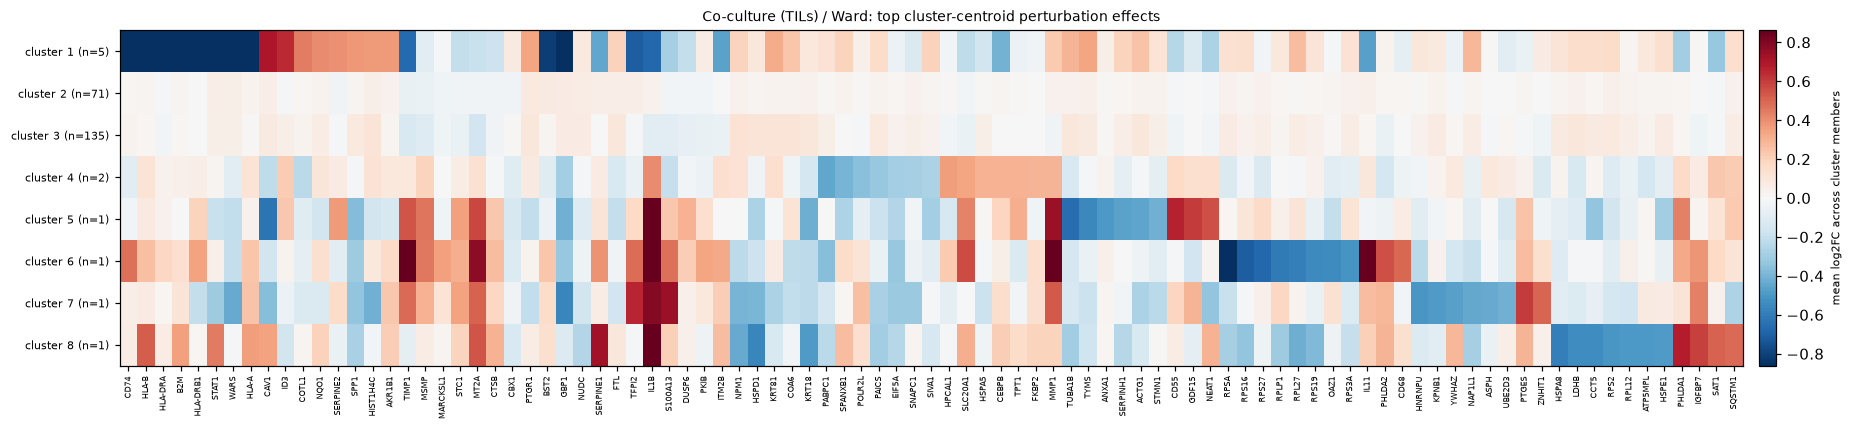

In [37]:
# Compact view of the strongest centroid effects; labels show why clusters separate.
ce = CLUSTER_EFFECTS[CLUSTER_EFFECTS.rank_type == 'centroid']
show_genes = list(dict.fromkeys(ce.sort_values(['cluster', 'direction', 'rank']).gene))
srec = labels[RECOMMENDED[0]][RECOMMENDED[1]]
centroids = pd.DataFrame({int(cl): lf[RECOMMENDED[0]].loc[srec.index[srec == cl], show_genes].mean()
                          for cl in sorted(set(srec) - {-1})}).T
lim = max(0.1, float(np.nanpercentile(np.abs(centroids.values), 98)))
fig, ax = plt.subplots(figsize=(max(8.5, 0.18 * len(show_genes)), 3.8), constrained_layout=True)
im = ax.imshow(centroids.values, aspect='auto', cmap='RdBu_r', vmin=-lim, vmax=lim)
ax.set_yticks(range(len(centroids))); ax.set_yticklabels(['cluster %s (n=%d)' %
    (cl, int((srec == cl).sum())) for cl in centroids.index], fontsize=7)
ax.set_xticks(range(len(show_genes))); ax.set_xticklabels(show_genes, rotation=90, fontsize=5.5)
ax.set_title('%s / %s: top cluster-centroid perturbation effects' %
             (CONDLAB[RECOMMENDED[0]], MSHORT[RECOMMENDED[1]]), fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01).set_label('mean log2FC across cluster members', fontsize=7)
fig.savefig('figures/task2_cluster_effect_heatmap.png', dpi=300, bbox_inches='tight')

**Figure 8.** Mean log2FC of the strongest up/down centroid genes for every cluster in the
recommended Co-culture partition. Gene ranks and the contrast against all other clusters are
available in `data/cluster_effect_genes.csv`; the full per-target ranks are stored separately.

In [38]:
export = pd.DataFrame([
    dict(perturbation=g, condition=c, method=m, cluster=int(v), is_noise=bool(v == -1),
         n_cells=int(ncells[c].loc[g]))
    for c in CONDS for m in METHODS for g, v in labels[c][m].items()])
export['pathway_label']     = export.perturbation.map(LAB_FULL)
export['paper_module']      = export.perturbation.map(PAPER_ONLY)
export['recommended']       = (export.condition == RECOMMENDED[0])  & (export.method == RECOMMENDED[1])
export['task3_usable_group']= ((export.condition == ALT_FOR_TASK3[0]) & (export.method == ALT_FOR_TASK3[1])
                               & ~export.is_noise)
export.to_parquet('data/perturbation_clusters.parquet', index=False)

provenance = dict(
    recommended_condition=RECOMMENDED[0], recommended_method=RECOMMENDED[1],
    criterion='max ARI(paper modules) x bootstrap stability among non-degenerate methods (n_clusters>1)',
    ari_paper=float(COMP[(COMP.condition == RECOMMENDED[0]) & (COMP.method == RECOMMENDED[1])].ari_paper.iloc[0]),
    stability=float(COMP[(COMP.condition == RECOMMENDED[0]) &
                         (COMP.method == RECOMMENDED[1])].stability_mean_pairwise_ari.iloc[0]),
    min_cells_per_perturbation=MIN_CELLS, n_genes_per_condition={c: len(gsel[c]) for c in CONDS},
    n_perturbations={c: len(keep[c]) for c in CONDS},
    dbscan_eps={c: round(EPS[c], 4) for c in CONDS},
    leiden_knn=LEIDEN_KNN, leiden_resolution={c: float(LEIDEN_RES[c]) for c in CONDS},
    best_k_by_silhouette={c: int(BEST_K_SIL[c]) for c in CONDS},
    k_hierarchical_and_kmeans=K_PART, hdbscan_min_cluster_size=MIN_CLUSTER_SIZE,
    dbscan_min_samples=MIN_SAMPLES, n_bootstraps=NB,
    effect_interpretation=dict(genes='condition-specific 1,500-gene signature set',
                               per_perturbation_rank='signed log2FC / SE',
                               cluster_rank='centroid log2FC and contrast vs other clusters'),
    dropped_promiscuous_labels=['UBA52', 'UBC', 'PPIA'],
    alt_for_task3=dict(condition=ALT_FOR_TASK3[0], method=ALT_FOR_TASK3[1],
                       cluster_sizes={int(k): int(v) for k, v in
                                      labels[ALT_FOR_TASK3[0]][ALT_FOR_TASK3[1]]
                                      .pipe(lambda s: s[s != -1].value_counts()).items()}),
    task3_note=('ward_euclid Co_culture has the highest composite score but is size-imbalanced '
                '(135/71/5/2/1/1/1/1). For a whole-module holdout, the hdbscan Co_culture clusters '
                '(23/17/7 members, 170 unclustered) are more usable; column task3_usable_group flags them.'))
json.dump(provenance, open('data/perturbation_clusters_provenance.json', 'w'), indent=2)

CELL_SUMMARY.to_csv('data/cell_level_cluster_summary.csv', index=False)
CELLARI.to_csv('data/cell_level_ari_vs_perturbation.csv', index=False)
pd.concat([CELLTAB[c][k].assign(condition=c, method=k)
           for c in CONDS for k in ['leiden', 'louvain', 'kmeans']]
          ).to_csv('data/cell_level_dominant_cluster.csv', index=False)
print('%d rows exported to data/perturbation_clusters.parquet' % len(export))

4536 rows exported to data/perturbation_clusters.parquet
